### Getter Insure AI - Insurance Cross-Sell Engine Inside Banking Transactions
##### Bima Kiganjani
By Shawn Irungu

### Project Overview
The Getter Insurance AI is an AI‑powered recommendation engine designed to intelligently identify insurance needs based on a customer’s real‑time banking behavior, financial profile, and life events.
Instead of relying solely on human sales teams or passive marketing, the system embeds insurance recommendations directly into banking channels - such as the mobile app, internet banking, and automated SMS/Email triggers.

### The Problem

Today, bancassurance cross‑selling faces several limitations such as:
1. Low customer engagement - Customers often do not encounter insurance offers unless manually contacted.
2. No contextual relevance - Recommendations are not based on the customer’s actual financial behavior or life events.
3. Limited data-driven insights - Banks rarely leverage transactional patterns to infer insurance needs.
4. Sales team dependency - Cross‑sell performance depends heavily on Sales Team, RM follow-ups and branch visits.

### Project Goal

To build a fully automated, data-driven recommendation system that predicts the right insurance product for the right customer at the right time.

This is achieved using machine learning models trained on:
i) Customer demographics
ii) Income segmentation
iii) Banking transactions
iv) Spending categories
v) Digital engagement
vi) Existing insurance policiesProject Objectives

1. Deliver Personalized, Real-Time Insurance Recommendations by identifying customer life events such as:
i) Salary credit → Life Cover
ii) School fees payment → Education Cover
iii) Travel bookings → Travel Insurance
iv) Electronics purchase → Gadget Insurance
v) Loan disbursements → Credit Life Cover
vi) Vehicle & Fuel Purchase → Motor Insurance
vii) Hospital Bill & Drug Purchase → Medical Insurance. etc

2. Automate Bancassurance Lead Generation
Remove dependence on manual outreach - Auto-generate leads for RMs or trigger self-service digital flows

3. Improve Customer Financial Protection - Ensure customers have adequate protection at key life moments - Reduce underinsurance caused by low awareness

4. Increase Bancassurance Revenue - Drive higher conversion rates by expanding insurance penetration through digital channels

The model then surfaces personalized offers wherever the customer interacts with the bank

### Project Objectives

1. Deliver Personalized, Real-Time Insurance Recommendations by identifying customer life events such as:
i) Salary credit → Life Cover
ii) School fees payment → Education Cover
iii) Travel bookings → Travel Insurance
iv) Electronics purchase → Gadget Insurance
v) Loan disbursements → Credit Life Cover
vi) Vehicle & Fuel Purchase → Motor Insurance
vii) Hospital Bill & Drug Purchase → Medical Insurance. etc

2. Automate Bancassurance Lead Generation
Remove dependence on manual outreach - Auto-generate leads for RMs or trigger self-service digital flows

3. Improve Customer Financial Protection - Ensure customers have adequate protection at key life moments - Reduce underinsurance caused by low awareness

4. Increase Bancassurance Revenue - Drive higher conversion rates by expanding insurance penetration through digital channels


#### _Import Libraries_

In [918]:
# Import Libraries
# data manipulation
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing & feature engineering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 

#classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

# Model evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

#Miscellaneous
import joblib

# Warnings
import warnings
warnings.filterwarnings('ignore')


#### _Load Datasets_

In [919]:
customers = pd.read_csv('customers.csv')
transactions = pd.read_csv('transactions.csv')
policies = pd.read_csv('policies.csv')

In [920]:
def dataframe_summary(df, name="Dataset"):
    """
    Print a comprehensive summary of a pandas DataFrame including:
    - Basic information
    - Descriptive statistics
    - Missing values analysis
    - Data types distribution
    
    
    
    Parameters:
    - df (pd.DataFrame): The DataFrame to analyze
    - name (str): Optional name for the dataset (for display purposes)
    """
    
    # Create a separator line for better readability
    separator = "=" * 70
    
    print(f"\n{separator}")
    print(f" COMPREHENSIVE SUMMARY FOR: {name.upper()}")
    print(f"{separator}\n")
    
    # 1. Basic Information Section
    print(" BASIC INFORMATION")
    print(f"- Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"- Total Cells: {df.size:,}")
    print(f"- Duplicate Rows: {df.duplicated().sum():,} ({df.duplicated().mean():.1%})")
    print("\n")
    
    # 2. Data Types Overview
    print(" DATA TYPES DISTRIBUTION")
    dtype_counts = df.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"- {dtype}: {count} columns")
    print("\n")
    
    # 3. Descriptive Statistics
    print(" DESCRIPTIVE STATISTICS (NUMERICAL COLUMNS)")
    print(df.describe(include=[np.number]).transpose())
    print("\n")
    
    # 4. Categorical Data Summary
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(categorical_cols) > 0:
        print(" CATEGORICAL DATA SUMMARY")
        for col in categorical_cols:
            print(f"\nColumn: {col}")
            print(f"- Unique values: {df[col].nunique()}")
            print(f"- Top value: {df[col].mode().values[0]} (count: {df[col].value_counts().max()})")
    print("\n")
    
    # Information
    print(" INFORMATION")
    print(df.info())
    print("\n")

    # 5. Missing Values Analysis
    print(" MISSING VALUES ANALYSIS")
    missing_values = df.isnull().sum()
    missing_percent = (missing_values / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Missing Values': missing_values,
        'Percentage (%)': missing_percent
    }).sort_values('Percentage (%)', ascending=False)
    
    # Only show columns with missing valuesdef dataframe_summary(df, name="Dataset"):
    """
    Print a comprehensive summary of a pandas DataFrame including:
    - Basic information
    - Descriptive statistics
    - Missing values analysis
    - Data types distribution
    
    
    
    Parameters:
    - df (pd.DataFrame): The DataFrame to analyze
    - name (str): Optional name for the dataset (for display purposes)
    """
    
    # Create a separator line for better readability
    separator = "=" * 70
    
    print(f"\n{separator}")
    print(f" COMPREHENSIVE SUMMARY FOR: {name.upper()}")
    print(f"{separator}\n")
    
    # 1. Basic Information Section
    print(" BASIC INFORMATION")
    print(f"- Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"- Total Cells: {df.size:,}")
    print(f"- Duplicate Rows: {df.duplicated().sum():,} ({df.duplicated().mean():.1%})")
    print("\n")
    
    # 2. Data Types Overview
    print(" DATA TYPES DISTRIBUTION")
    dtype_counts = df.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"- {dtype}: {count} columns")
    print("\n")
    
    # 3. Descriptive Statistics
    print(" DESCRIPTIVE STATISTICS (NUMERICAL COLUMNS)")
    print(df.describe(include=[np.number]).transpose())
    print("\n")
    
    # 4. Categorical Data Summary
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(categorical_cols) > 0:
        print(" CATEGORICAL DATA SUMMARY")
        for col in categorical_cols:
            print(f"\nColumn: {col}")
            print(f"- Unique values: {df[col].nunique()}")
            print(f"- Top value: {df[col].mode().values[0]} (count: {df[col].value_counts().max()})")
    print("\n")
    
    # Information
    print(" INFORMATION")
    print(df.info())
    print("\n")

    # 5. Missing Values Analysis
    print(" MISSING VALUES ANALYSIS")
    missing_values = df.isnull().sum()
    missing_percent = (missing_values / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Missing Values': missing_values,
        'Percentage (%)': missing_percent
    }).sort_values('Percentage (%)', ascending=False)
    
    # Only show columns with missing values
    missing_df = missing_df[missing_df['Missing Values'] > 0]
    
    if len(missing_df) > 0:
        print(missing_df)
        print(f"\nTotal missing values: {missing_values.sum():,}")
        print(f"Percentage of total data: {missing_percent.sum()/df.size:.2%}")
    else:
        print("No missing values found in the dataset!")
    print("\n")
    missing_df = missing_df[missing_df['Missing Values'] > 0]
    
    if len(missing_df) > 0:
        print(missing_df)
        print(f"\nTotal missing values: {missing_values.sum():,}")
        print(f"Percentage of total data: {missing_percent.sum()/df.size:.2%}")
    else:
        print("No missing values found in the dataset!")
    print("\n")

#### _customers summary_

In [921]:
dataframe_summary(customers, "customers Dataset")


 COMPREHENSIVE SUMMARY FOR: CUSTOMERS DATASET

 BASIC INFORMATION
- Shape: 7000 rows, 7 columns
- Total Cells: 49,000
- Duplicate Rows: 0 (0.0%)


 DATA TYPES DISTRIBUTION
- object: 5 columns
- float64: 1 columns
- int64: 1 columns


 DESCRIPTIVE STATISTICS (NUMERICAL COLUMNS)
              count         mean          std   min      25%     50%      75%  \
customer_id  7000.0  3500.500000  2020.870275   1.0  1750.75  3500.5  5250.25   
age          1649.0    48.324439    17.969388  18.0    33.00    48.0    64.00   

                max  
customer_id  7000.0  
age            79.0  


 CATEGORICAL DATA SUMMARY

Column: income_band
- Unique values: 3
- Top value: Low (count: 1415)

Column: customer_segment
- Unique values: 4
- Top value: Affluent (count: 1776)

Column: occupation
- Unique values: 639
- Top value: Careers adviser (count: 22)

Column: city
- Unique values: 31
- Top value: Bomet (count: 265)

Column: kyc_risk_rating
- Unique values: 3
- Top value: Medium (count: 1785)


 IN

#### _policies summary_

In [922]:
dataframe_summary(policies, "policies dataset")


 COMPREHENSIVE SUMMARY FOR: POLICIES DATASET

 BASIC INFORMATION
- Shape: 7000 rows, 7 columns
- Total Cells: 49,000
- Duplicate Rows: 0 (0.0%)


 DATA TYPES DISTRIBUTION
- object: 4 columns
- int64: 2 columns
- float64: 1 columns


 DESCRIPTIVE STATISTICS (NUMERICAL COLUMNS)
                 count           mean          std       min        25%  \
policy_id       7000.0  503499.500000  2020.870275  500000.0  501749.75   
customer_id     7000.0    3470.135143  2025.244587       1.0    1707.50   
premium_amount  2349.0    7664.403150  4355.225467     205.0    3842.00   

                     50%        75%       max  
policy_id       503499.5  505249.25  506999.0  
customer_id       3445.0    5213.00    7000.0  
premium_amount    7696.0   11556.00   14998.0  


 CATEGORICAL DATA SUMMARY

Column: product_type
- Unique values: 5
- Top value: Motor (count: 1011)

Column: start_date
- Unique values: 1094
- Top value: 2022-05-05 (count: 14)

Column: end_date
- Unique values: 1091
- Top val

#### _transactions summary_

In [923]:
dataframe_summary(transactions, "Transactions Dataset")


 COMPREHENSIVE SUMMARY FOR: TRANSACTIONS DATASET

 BASIC INFORMATION
- Shape: 7000 rows, 7 columns
- Total Cells: 49,000
- Duplicate Rows: 0 (0.0%)


 DATA TYPES DISTRIBUTION
- object: 3 columns
- float64: 2 columns
- int64: 2 columns


 DESCRIPTIVE STATISTICS (NUMERICAL COLUMNS)
                 count           mean            std       min        25%  \
transaction_id  7000.0  103499.500000    2020.870275  100000.0  101749.75   
customer_id     7000.0    3530.691000    2039.733950       1.0    1753.75   
amount          2366.0  151011.940406   86389.186047     223.0   77029.25   
balance_after   3535.0  402723.507779  228744.147137     163.0  207544.00   

                     50%        75%       max  
transaction_id  103499.5  105249.25  106999.0  
customer_id       3549.5    5311.00    7000.0  
amount          150066.0  226386.25  299966.0  
balance_after   403253.0  598351.50  799773.0  


 CATEGORICAL DATA SUMMARY

Column: transaction_date
- Unique values: 731
- Top value: 2025

In [924]:
customers.head()

,customer_id,age,income_band,customer_segment,occupation,city,kyc_risk_rating
0,1,NaN,NaN,SME,"Development worker, community",Homa Bay,High
1,2,NaN,NaN,SME,"Designer, graphic",Narok,Medium
2,3,NaN,High,Affluent,Interior and spatial designer,Garissa,Low
3,4,NaN,Low,SME,"Accountant, chartered public finance",Isiolo,High
4,5,38.0,NaN,,"Programmer, applications",Siaya,NaN


In [925]:
transactions.head()

,transaction_id,customer_id,transaction_date,amount,category,channel,balance_after
0,100000,5629,2025-11-22,NaN,NaN,USSD,NaN
1,100001,442,2025-10-03,NaN,Groceries,Internet Banking,704463.0
2,100002,1438,2025-06-30,NaN,NaN,App,NaN
3,100003,3188,2025-06-28,NaN,Groceries,USSD,400125.0
4,100004,4999,2024-08-02,33646.0,Electronics,NaN,NaN


In [926]:
policies.head()

,policy_id,customer_id,product_type,premium_amount,start_date,end_date,status
0,500000,4365,Medical,NaN,2023-11-01,2028-04-09,NaN
1,500001,5553,NaN,NaN,2023-02-21,2028-07-11,NaN
2,500002,1049,Motor,NaN,2024-10-31,2027-01-31,NaN
3,500003,1368,Motor,NaN,2023-08-17,2026-08-07,Pending
4,500004,2032,Medical,NaN,2024-02-04,2027-06-27,NaN


#### _Merge the 3 datasets_

In [927]:
data1 = pd.merge(customers, transactions,how = 'left', on='customer_id')
#data1.head()
data = pd.merge(data1, policies, how='left', on='customer_id')
data.tail()

,customer_id,age,income_band,customer_segment,occupation,city,kyc_risk_rating,transaction_id,transaction_date,amount,category,channel,balance_after,policy_id,product_type,premium_amount,start_date,end_date,status
13125,6997,NaN,Low,Mass,"Librarian, academic",NaN,Low,103843.0,2025-02-28,NaN,NaN,Branch,201484.0,504902.0,Medical,2760.0,2023-11-12,2026-04-16,Lapsed
13126,6998,NaN,NaN,Mass,Advice worker,Siaya,Low,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13127,6999,NaN,NaN,SME,Accommodation manager,Thika,NaN,101824.0,2025-12-24,207746.0,Travel,Branch,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13128,7000,NaN,NaN,SME,Clinical cytogeneticist,Isiolo,High,102885.0,2025-03-04,NaN,Travel,App,359954.0,500436.0,Motor,NaN,2022-05-05,2027-06-09,Pending
13129,7000,NaN,NaN,SME,Clinical cytogeneticist,Isiolo,High,102885.0,2025-03-04,NaN,Travel,App,359954.0,505502.0,Travel,11011.0,2024-04-01,2027-05-28,Lapsed


In [928]:
dataframe_summary(data, "merged dataset")


 COMPREHENSIVE SUMMARY FOR: MERGED DATASET

 BASIC INFORMATION
- Shape: 13130 rows, 19 columns
- Total Cells: 249,470
- Duplicate Rows: 0 (0.0%)


 DATA TYPES DISTRIBUTION
- object: 12 columns
- float64: 6 columns
- int64: 1 columns


 DESCRIPTIVE STATISTICS (NUMERICAL COLUMNS)
                  count           mean            std       min        25%  \
customer_id     13130.0    3502.416451    2028.837946       1.0    1748.00   
age              3099.0      48.072927      17.711441      18.0      33.00   
transaction_id   9503.0  103512.529201    2019.925372  100000.0  101768.50   
amount           3225.0  150486.335194   86721.329301     223.0   77018.00   
balance_after    4826.0  404400.198094  227537.392043     163.0  212532.75   
policy_id        9590.0  503493.981543    2017.631271  500000.0  501744.00   
premium_amount   3192.0    7579.144110    4364.338000     205.0    3679.50   

                     50%        75%       max  
customer_id       3492.0    5252.00    7000.0  

#### _merged dataset to csv_

In [929]:
data.to_csv('data_merged.csv', index =False)

#### _replace missing values in label_

In [930]:
choices = ['Life','Medical','Motor','Travel','Gadget']
idx = data['product_type'].index
first =idx[:2150]# First 2500 blanks - Education
rest =idx[2150:] # Remaining blanks - Random product types
data.loc[first,'product_type'] = 'Education'
data.loc[rest,'product_type'] =np.random.choice(choices,size=len(rest))

In [931]:
print('Number of unique Values')
for col in data.columns:
    print(f"{col}: {data[col].nunique()}")

Number of unique Values
customer_id: 7000
age: 62
income_band: 3
customer_segment: 4
occupation: 639
city: 31
kyc_risk_rating: 3
transaction_id: 7000
transaction_date: 731
amount: 2355
category: 5
channel: 4
balance_after: 3521
policy_id: 7000
product_type: 6
premium_amount: 2181
start_date: 1094
end_date: 1091
status: 3


In [932]:
data.to_csv('data_merged.csv', index =False)

### Split Data & Cleaning Target

In [933]:
X=data.drop(columns=['product_type', 'policy_id', 'transaction_id'])
y=data['product_type']


In [934]:
# confirm no missing values in label
y.value_counts()

Gadget       2280
Life         2214
Travel       2186
Motor        2170
Education    2150
Medical      2130
Name: product_type, dtype: int64

### Clean Predictors (X train, X test)
1. fix missing values
2. normalize text columns
3. fix numeric columns
4. convert date time
5. remove duplicates
6. handle outliers

In [935]:
## Clean Categorical Predictors
# clean them with lowercase, title , strip convert blanks to NaN
cat_cols = ['income_band', 'customer_segment', 'occupation', 'city', 
            'kyc_risk_rating', 'category', 'channel', 'status']

for col in cat_cols:
    X[col] = X[col].astype(str).str.strip()
    X[col] = X[col].replace([ "", "nan", "None", " "], np.nan)
    X[col] = X[col].str.title()
    

In [936]:
# clean numeric predictors
# convert all numeric safely
# fill missing numerics with median

num_cols = ['age', 'amount', 'balance_after', 'premium_amount']

for col in num_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')
    X[col] = X[col].fillna(X[col].median())

In [937]:
# Clan Date Columns

date_cols = ['transaction_date', 'start_date', 'end_date']

for col in date_cols:
    X[col] = pd.to_datetime(X[col], errors='coerce')
    X[col] = X[col].fillna(X[col].mean())
    

In [938]:
# Create date based features
for col in date_cols:
    X[col + '_year'] = X[col].dt.year
    X[col + '_month'] = X[col].dt.month
    X[col + '_day'] = X[col].dt.day
    X[col + '_weekday'] = X[col].dt.weekday
    

In [939]:
# Remove Duplicates
X=X.drop_duplicates()


In [940]:
# Verify Cleaning Results

dataframe_summary( X, "Predictors")

# this tells we still have some missing values in the predictors, we can handle them with imputation or drop 
# them depending on the percentage of missingness and importance of the feature.



 COMPREHENSIVE SUMMARY FOR: PREDICTORS

 BASIC INFORMATION
- Shape: 13130 rows, 28 columns
- Total Cells: 367,640
- Duplicate Rows: 0 (0.0%)


 DATA TYPES DISTRIBUTION
- int64: 13 columns
- object: 8 columns
- float64: 4 columns
- datetime64[ns]: 3 columns


 DESCRIPTIVE STATISTICS (NUMERICAL COLUMNS)
                            count           mean            std     min  \
customer_id               13130.0    3502.416451    2028.837946     1.0   
age                       13130.0      47.253237       8.615627    18.0   
amount                    13130.0  148701.975324   42986.242751   223.0   
balance_after             13130.0  405559.344097  137941.366160   163.0   
premium_amount            13130.0    7603.255598    2151.665292   205.0   
transaction_date_year     13130.0    2024.786900       0.564639  2024.0   
transaction_date_month    13130.0       5.520259       3.323325     1.0   
transaction_date_day      13130.0      15.553694       7.511865     1.0   
transaction_date_week

In [941]:
X['income_band'].value_counts()

Low       2721
Medium    2613
High      2430
Name: income_band, dtype: int64

In [942]:
X['income_band'].isna().sum()

5366

In [943]:
# Dealing with missing values in categorical features

observed = X['income_band'].value_counts(normalize=True)
X['income_band'] = X['income_band'].fillna(
    pd.Series(np.random.choice(observed.index, size=X['income_band'].isna().sum(), p=observed.values))
)

X['income_band']= X['income_band'].fillna('Vary')
X['customer_segment']= X['customer_segment'].fillna('Gold')
X['occupation']= X['occupation'].fillna('Labourer')
X['city']= X['city'].fillna('Thika Road')
X['kyc_risk_rating']= X['kyc_risk_rating'].fillna('Low')
X['category']= X['category'].fillna('Personal')
X['channel']= X['channel'].fillna('App')
X['status']= X['status'].fillna('Active')

In [944]:
mapping = {'Mass': 'Go Banking', 'Affluent': 'Platinum', 'Sme': 'SME'}
X['customer_segment']= X['customer_segment'].replace(mapping)


In [945]:
cleaned = pd.concat([X, y], axis=1)

#cleaned.to_csv('data_cleaned.csv', index=False)


### _VISUALIZATION_

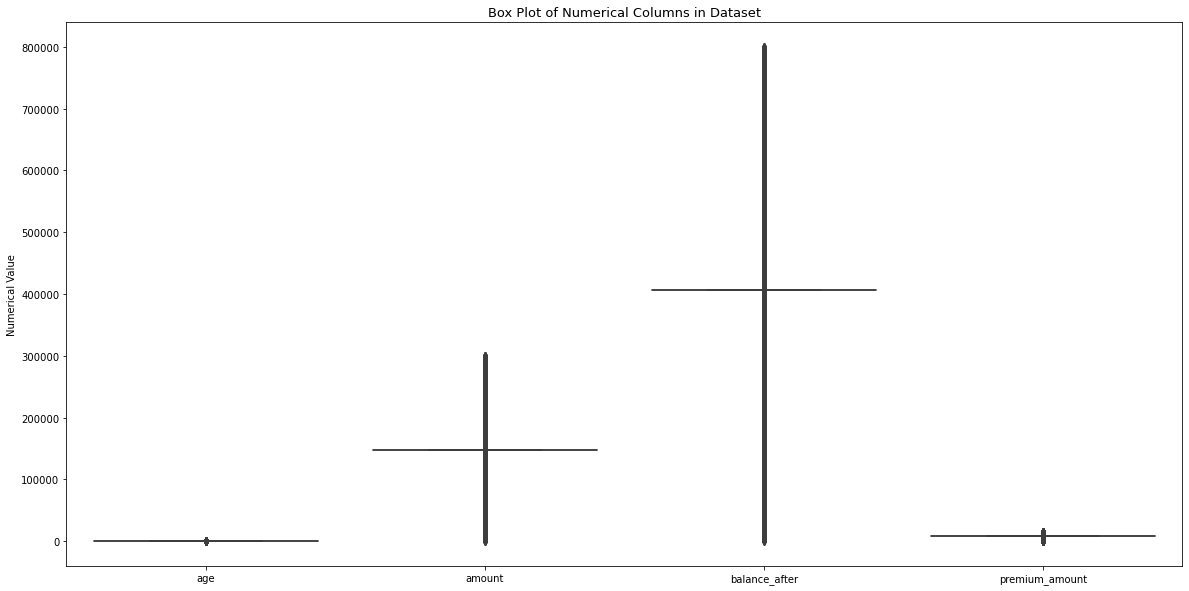

In [946]:
# Plotting box plots of numerical columns - num_cols
plt.figure(figsize=(20, 10))
sns.boxplot(data=[X[col] for col in num_cols])
plt.title("Box Plot of Numerical Columns in Dataset", fontsize=13)
plt.ylabel("Numerical Value")
plt.xticks(range(0,4), num_cols)
plt.show()

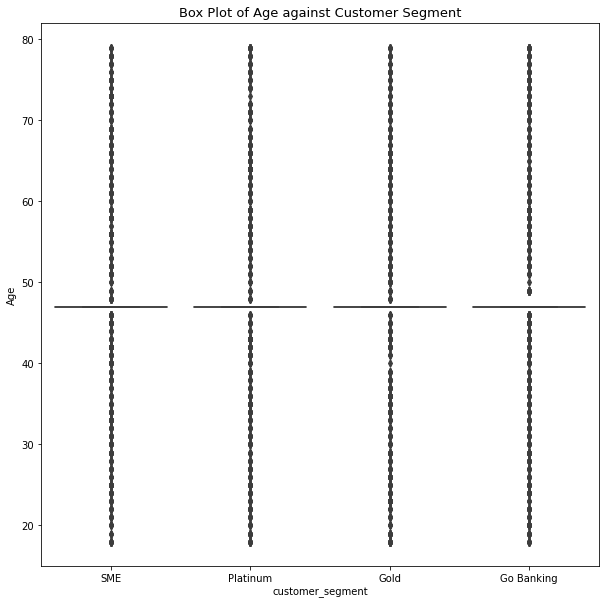

In [947]:
# for AGe
plt.figure(figsize=(10, 10))
sns.boxplot(x='customer_segment', y = 'age', data=X)
plt.title("Box Plot of Age against Customer Segment", fontsize=13)
plt.ylabel("Age")
plt.xticks(range(0,len(X['customer_segment'].unique())), X['customer_segment'].unique())
plt.show()

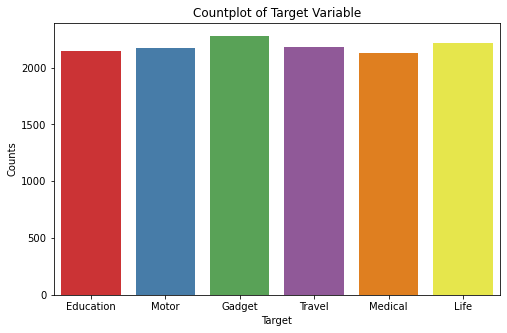

In [948]:
# Plot distribution of target variable.
fig, ax = plt.subplots(figsize=(8,5))
sns.countplot(y, palette='Set1', ax=ax)
y_labels = y.unique()

# Add labels
plt.title('Countplot of Target Variable')
plt.xlabel('Target')
#ax.set_xticklabels(x_labels, fontsize=10)
plt.ylabel('Counts')
plt.show()

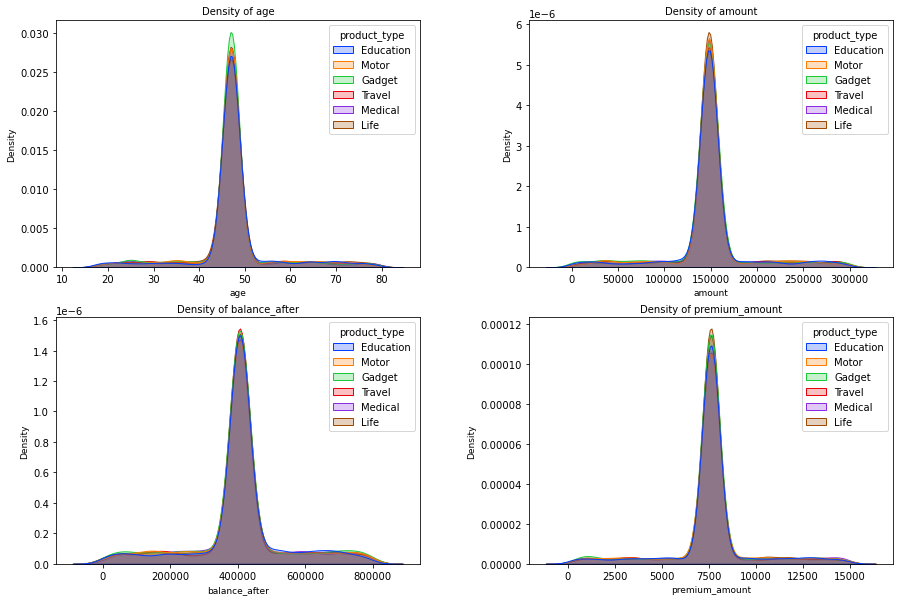

In [949]:
# Set up the subplots with 2 columns and increased spacing
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
fig.subplots_adjust(hspace=0.2, wspace=0.3)  # Increase hspace and wspace

# Create count bar plots for continuous variables

for i, column in enumerate(num_cols):
    row, col = i // 2, i % 2
    sns.kdeplot(data=X, x=column, hue=y, palette='bright', 
                fill=True, ax=axes[row, col])
    axes[row, col].set_title(f'Density of {column}', fontsize=10)
    axes[row, col].set_xlabel(column, fontsize=9)
    axes[row, col].set_ylabel('Density', fontsize=9)
    
plt.savefig('images/density_of_target_class_vs_numerical_features.jpg')
plt.show()

This shows normal distribution

#### _preprocessing_

In [950]:
date_cols = X.select_dtypes(include=['datetime64']).columns
X = X.drop(columns=date_cols)

In [951]:
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

#### Split Into Train Test Split

In [952]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [953]:
# perform standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Create Baseline Model - Logistic Regression

In [954]:
# Logistic Regression Model
logistic_model = LogisticRegression(random_state=42)

# Fit the model on training data
logistic_model.fit(X_train_scaled, y_train)

# predict on the test set
y_pred_log = logistic_model.predict(X_test_scaled)
y_score_log = logistic_model.fit(X_train, y_train).decision_function(X_test)

In [955]:
def model_score(model, y_true, y_pred, y_train, y_pred_train):
        # Print classification report, accuracy, precision, recall, f1_score 
        separator = "=" * 70

        print(f"\n{separator}")
        print('MODEL REPORT')
        print(f'{separator}')
        print(classification_report(y_true, y_pred))
        print(f"\n{separator}")

        print('MODEL METRICS - TRAIN SET')
        print(f'{separator}')
        print("Overall accuracy score", accuracy_score(y_train, y_pred_train))
        print("Overall precision score", precision_score(y_train, y_pred_train, average='weighted'))
        print("Overall recall score", recall_score(y_train, y_pred_train, average='weighted'))
        print("Overall F1-score", f1_score(y_train, y_pred_train, average='weighted'))


        print('MODEL METRICS - TEST SET')
        print(f'{separator}')
        print("Overall accuracy score", accuracy_score(y_true, y_pred))
        print("Overall precision score", precision_score(y_true, y_pred, average='weighted'))
        print("Overall recall score", recall_score(y_true, y_pred, average='weighted'))
        print("Overall F1-score", f1_score(y_true, y_pred, average='weighted'))

        #print(f"\n{separator}")
        #print('ROC AUC SCORE')
        #print(f'{separator}')
        #fpr, tpr, thresholds = roc_curve(y_test, y_score_log, multi_class='ovr')
        #print("AUC", auc(fpr, tpr))

        print(f"\n{separator}")
        print('CONFUSION MATRIX')
        print(f'{separator}')

        # Print a confusion matrix    
        cnf_matrix = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix, display_labels=model.classes_)      
        return disp.plot(cmap='Reds')


MODEL REPORT
              precision    recall  f1-score   support

   Education       0.93      0.95      0.94       430
      Gadget       0.19      0.21      0.20       456
        Life       0.16      0.16      0.16       443
     Medical       0.21      0.20      0.21       426
       Motor       0.21      0.21      0.21       434
      Travel       0.22      0.19      0.20       437

    accuracy                           0.32      2626
   macro avg       0.32      0.32      0.32      2626
weighted avg       0.32      0.32      0.32      2626


MODEL METRICS - TRAIN SET
Overall accuracy score 0.2638042650418888
Overall precision score 0.2521795356895807
Overall recall score 0.2638042650418888
Overall F1-score 0.16321566765183423
MODEL METRICS - TEST SET
Overall accuracy score 0.31911652703731913
Overall precision score 0.31750011302038134
Overall recall score 0.31911652703731913
Overall F1-score 0.3179275516025295

CONFUSION MATRIX


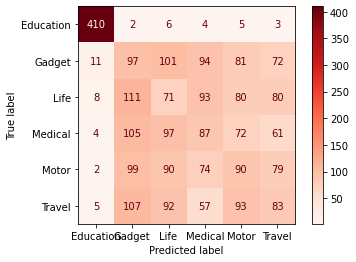

In [956]:
model_score(logistic_model, y_test, y_pred_log, y_train, logistic_model.predict(X_train_scaled))